In [1]:
import boto3
import pandas as pd

# S3 details
bucket = "instance-earthquake-data"
key = "INSTANCE/metadata_Instance_events_v3.csv"

# Where to save it locally
local_path = "metadata_Instance_events_v3.csv"

# Create S3 client
s3 = boto3.client("s3")

# Download from S3 to your laptop
s3.download_file(bucket, key, local_path)

# Load into pandas
metadata = pd.read_csv(local_path)

metadata.head()

/home/ec2-user/Earthquake/.venv/lib64/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/tmp/ipykernel_4568/2407588876.py:18: DtypeWarning: Columns (23,24,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(local_path)


,source_id,station_network_code,station_code,station_location_code,station_channels,station_latitude_deg,station_longitude_deg,station_elevation_m,station_vs_30_mps,station_vs_30_detail,...,trace_sa10_cmps2,trace_sa30_cmps2,trace_name,trace_GPD_P_number,trace_GPD_S_number,trace_EQT_number_detections,trace_EQT_P_number,trace_EQT_S_number,trace_deconvolved_units,source_type
0,10000541,MN,AQU,NaN,HH,42.35400,13.40500,710.0,485.0,Vs30 extracted from ShakeMap,...,0.000700,0.000188,10000541.MN.AQU..HH,1.0,1.0,1.0,1.0,1.0,mps,earthquake
1,10000541,MN,AQU,NaN,HL,42.35400,13.40500,710.0,485.0,Vs30 extracted from ShakeMap,...,0.001325,0.000486,10000541.MN.AQU..HL,NaN,NaN,NaN,NaN,NaN,mps2,earthquake
2,10000541,IV,ARRO,NaN,EH,42.57917,12.76567,253.0,549.0,Vs30 extracted from ShakeMap,...,0.000450,0.000217,10000541.IV.ARRO..EH,2.0,1.0,1.0,1.0,1.0,mps,earthquake
3,10000541,IV,ASSB,NaN,HH,43.04260,12.65870,734.0,412.0,Vs30 extracted from ShakeMap,...,0.000670,0.000145,10000541.IV.ASSB..HH,1.0,7.0,1.0,1.0,1.0,mps,earthquake
4,10000541,IV,ATCC,NaN,EH,43.18514,12.63994,557.0,667.0,Vs30 extracted from ShakeMap,...,0.000559,0.000277,10000541.IV.ATCC..EH,1.0,3.0,1.0,1.0,1.0,mps,earthquake


In [2]:
print(metadata.shape)

(1159249, 115)


In [6]:
print(metadata.keys().tolist())

['source_id', 'station_network_code', 'station_code', 'station_location_code', 'station_channels', 'station_latitude_deg', 'station_longitude_deg', 'station_elevation_m', 'station_vs_30_mps', 'station_vs_30_detail', 'source_origin_time', 'source_latitude_deg', 'source_longitude_deg', 'source_depth_km', 'source_origin_uncertainty_s', 'source_latitude_uncertainty_deg', 'source_longitude_uncertainty_deg', 'source_depth_uncertainty_km', 'source_stderror_s', 'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_magnitude', 'source_magnitude_type', 'source_mt_eval_mode', 'source_mt_status', 'source_mt_scalar_moment_Nm', 'source_mechanism_strike_dip_rake', 'source_mechanism_moment_tensor', 'path_travel_time_P_s', 'path_travel_time_S_s', 'path_residual_P_s', 'path_residual_S_s', 'path_ep_distance_km', 'path_hyp_distance_km', 'path_azimuth_deg', 'path_backazimuth_deg', 'path_weight_phase_location_P', 'path_weight_phase_location_S', 'trace_start_time', 'trace_dt_s', 'trace_npts', 'trace_

In [5]:
num_earthquakes = metadata["source_id"].nunique()
print(num_earthquakes)

54008


In [9]:
print(metadata["source_origin_time"])
metadata["source_origin_time"] = pd.to_datetime(metadata["source_origin_time"])

metadata["year"] = metadata["source_origin_time"].dt.year
metadata["month"] = metadata["source_origin_time"].dt.month
metadata["date"] = metadata["source_origin_time"].dt.date

0          2016-11-16T01:35:56.21Z
1          2016-11-16T01:35:56.21Z
2          2016-11-16T01:35:56.21Z
3          2016-11-16T01:35:56.21Z
4          2016-11-16T01:35:56.21Z
                    ...           
1159244    2012-06-03T19:20:43.39Z
1159245    2012-06-03T19:20:43.39Z
1159246    2012-06-03T19:20:43.39Z
1159247    2012-06-03T19:20:43.39Z
1159248    2012-06-03T19:20:43.39Z
Name: source_origin_time, Length: 1159249, dtype: object


In [10]:
print(metadata["year"].min())
print(metadata["year"].max())

2005
2020


In [27]:
train_ids = metadata[metadata["year"] < 2018]
val_ids = metadata[metadata["year"] == 2018]
test_ids = metadata[metadata["year"] > 2018]


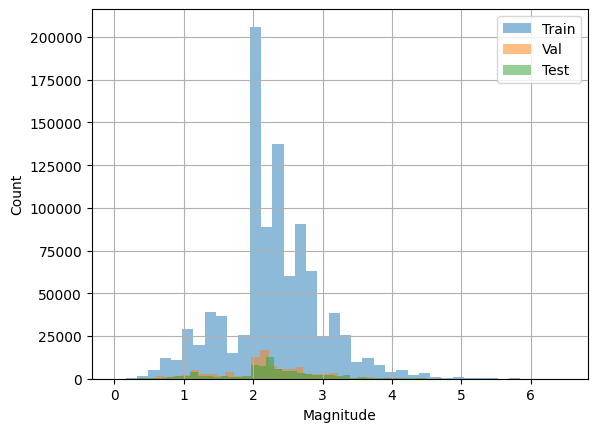

In [28]:
import matplotlib.pyplot as plt

train_ids["source_magnitude"].hist(bins=40, alpha=0.5, label="Train")
val_ids["source_magnitude"].hist(bins=40, alpha=0.5, label="Val")
test_ids["source_magnitude"].hist(bins=40, alpha=0.5, label="Test")

plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [29]:
for name, df in [
    ("train", train_ids),
    ("val", val_ids),
    ("test", test_ids)
]:
    print(name)
    print(df.groupby("source_id")["source_magnitude"].first().describe())
    print()

train
count    47273.000000
mean         1.986747
std          0.686307
min          0.000000
25%          1.500000
50%          2.100000
75%          2.400000
max          6.500000
Name: source_magnitude, dtype: float64

val
count    3711.000000
mean        1.821719
std         0.694897
min         0.100000
25%         1.200000
50%         2.000000
75%         2.300000
max         5.100000
Name: source_magnitude, dtype: float64

test
count    3024.000000
mean        1.868849
std         0.719826
min         0.100000
25%         1.200000
50%         2.000000
75%         2.300000
max         4.500000
Name: source_magnitude, dtype: float64



In [30]:
bins = [0, 1, 2, 3, 4, 5, 6, 7]

for name, df in [
    ("train", train_ids),
    ("val", val_ids),
    ("test", test_ids)
]:
    events = df.groupby("source_id")["source_magnitude"].first()

    print(name)
    print(pd.cut(events, bins=bins).value_counts().sort_index())
    print()

train
source_magnitude
(0, 1]     5068
(1, 2]    17608
(2, 3]    22142
(3, 4]     2200
(4, 5]      230
(5, 6]       19
(6, 7]        2
Name: count, dtype: int64

val
source_magnitude
(0, 1]     600
(1, 2]    1570
(2, 3]    1409
(3, 4]     123
(4, 5]       8
(5, 6]       1
(6, 7]       0
Name: count, dtype: int64

test
source_magnitude
(0, 1]     492
(1, 2]    1115
(2, 3]    1282
(3, 4]     127
(4, 5]       8
(5, 6]       0
(6, 7]       0
Name: count, dtype: int64



In [31]:
required_columns = [
    "source_magnitude",
    "trace_P_arrival_sample"
]
print(len(train_ids))
print(len(val_ids))
print(len(test_ids))
train_ids = train_ids.dropna(subset=required_columns)
val_ids   = val_ids.dropna(subset=required_columns)
test_ids  = test_ids.dropna(subset=required_columns)
print()
print(len(train_ids))
print(len(val_ids))
print(len(test_ids))

979487
96993
82769

979487
96993
82769


In [34]:
train_metadata = metadata[metadata["source_id"].isin(train_ids)][["trace_name", "trace_P_arrival_sample"]].dropna()

In [35]:
import numpy as np 
import h5py as h5 

In [37]:

waveforms = h5.File(
    "/data/Instance_events_counts.hdf5",
    "r"
)

In [ ]:
from sklearn.model_selection import train_test_split
event_ids = train_ids["source_id"].unique()

opt_event_ids, _ = train_test_split(
    event_ids,
    train_size=0.2,
    random_state=42
)
opt_event_ids2, _ = train_test_split(
    event_ids,
    train_size=0.4,
    random_state=42
)

train_optimize_architecture = train_ids[
    train_ids["source_id"].isin(opt_event_ids)
]
train_optimize_hyperparams = train_ids[
    train_ids["source_id"].isin(opt_event_ids2)
]

In [ ]:
architecture_indices = set(train_optimize_architecture.index)
hyperparam_indices = set(train_optimize_hyperparams.index)

channel_sum_full = np.zeros(3, dtype=np.float64)
channel_sqsum_full = np.zeros(3, dtype=np.float64)

channel_sum_architecture = np.zeros(3, dtype=np.float64)
channel_sqsum_architecture = np.zeros(3, dtype=np.float64)

channel_sum_hyperparams = np.zeros(3, dtype=np.float64)
channel_sqsum_hyperparams = np.zeros(3, dtype=np.float64)

countfull = 0
countarchitecture = 0
counthyperparams = 0

time = 300

for row in train_ids.itertuples():

    id = row.Index

    trace_name = row.trace_name
    p_arrival = int(row.trace_P_arrival_sample)

    waveform_time = waveforms["data"][trace_name][
        :, p_arrival:p_arrival + time
    ].astype(np.float64)

    if waveform_time.shape[1] != time:
        continue

    channel_sum = waveform_time.sum(axis=1)
    channel_sqsum = np.square(waveform_time).sum(axis=1)

    channel_sum_full += channel_sum
    channel_sqsum_full += channel_sqsum
    countfull += time

    if id in architecture_indices:
        channel_sum_architecture += channel_sum
        channel_sqsum_architecture += channel_sqsum
        countarchitecture += time

    if id in hyperparam_indices:
        channel_sum_hyperparams += channel_sum
        channel_sqsum_hyperparams += channel_sqsum
        counthyperparams += time


meanfull = channel_sum_full / countfull

stdfull = np.sqrt(
    channel_sqsum_full / countfull
    - meanfull ** 2
)

meanarchitecture = (
    channel_sum_architecture / countarchitecture
)

stdarchitecture = np.sqrt(
    channel_sqsum_architecture / countarchitecture
    - meanarchitecture ** 2
)

meanhyperparams = (
    channel_sum_hyperparams / counthyperparams
)

stdhyperparams = np.sqrt(
    channel_sqsum_hyperparams / counthyperparams
    - meanhyperparams ** 2
)

In [ ]:
np.save("train_mean_full.npy", meanfull)

np.save("train_std_full.npy", stdfull)

np.save("train_mean_architecture.npy", meanarchitecture)

np.save("train_std_architecture.npy", stdarchitecture)

np.save("train_mean_hyperparams.npy", meanhyperparams)

np.save("train_std_hyperparams.npy", stdhyperparams)

NameError: name 'np' is not defined

In [ ]:
np.save()